# Regressor Analysis

This notebook is reorganized into clear stages: environment setup, model/data loading, activation probing, regression evaluation, and interpretability checks.

## 1) Setup

In [28]:
import sys
from datetime import datetime
from pathlib import Path
import importlib

import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / 'src').exists():
            return candidate
    raise FileNotFoundError("Cannot find project root containing 'src' directory.")


PROJECT_ROOT = resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data.preparation import prepare_data
from src.models.builders import ModelBuilder
from src.train.config_setup import load_args_from_checkpoint, load_model_from_checkpoint
from src.utils.mask_utils import get_non_pad_mask
from src.utils.metrics import regression_metrics
from src.utils.utils import _to_np_datetime64_seconds, set_seed
import src.data.event_loader as loader
import src.utils.analysis as analysis
import src.utils.interpretability as interp

set_seed(0)
np.random.seed(0)
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
FIG_DIR = PROJECT_ROOT / 'notebooks' / 'figs'
FIG_BATCH_DIR = FIG_DIR / 'reg'
FIG_DIR.mkdir(parents=True, exist_ok=True)
FIG_BATCH_DIR.mkdir(parents=True, exist_ok=True)

data_start = [1970, 1, 1, 0, 0, 0]
t0_np = _to_np_datetime64_seconds(datetime(*data_start))

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'DEVICE: {DEVICE}')

PROJECT_ROOT: /root/autodl-tmp/chuandian_eq
DEVICE: cuda:0


## 2) Load Model and Data

In [29]:
CHECKPOINT_DIR = PROJECT_ROOT / 'checkpoints' / 'reg_mixer_attnpl_t_20260204-180531'
CHECKPOINT_PATH = CHECKPOINT_DIR / 'last_model_1.pth'
USE_TORCH_COMPILE = True
BATCH_SIZE = 32
BATCH_OFFSET_FROM_END = 3


def load_model_and_args(checkpoint_path: Path, device: torch.device, use_compile: bool = True):
    check_point = torch.load(checkpoint_path, map_location=device, weights_only=False)
    args = load_args_from_checkpoint(None, check_point)

    model_builder = ModelBuilder.by_name(args.model.lower())()
    model = model_builder(args, device)
    model, _, _ = load_model_from_checkpoint(model, check_point)

    if use_compile and hasattr(torch, 'compile'):
        model = torch.compile(model)

    model.eval()
    return model, args


model, args = load_model_and_args(CHECKPOINT_PATH, DEVICE, use_compile=USE_TORCH_COMPILE)
args.batch_size = BATCH_SIZE

base_dir = PROJECT_ROOT / 'data' / args.dataset
df, train_loader, val_loader, test_loader, catalog_ds = prepare_data(base_dir=str(base_dir), args=args)
data_loader = loader.get_dataloader(
    catalog_ds,
    batch_size=args.batch_size,
    shuffle=False,
    task_type=args.task_type,
)


def collect_device_batches(loader_obj, device: torch.device):
    xs, ys = [], []
    for x_batch, y_batch in loader_obj:
        xs.append(x_batch.to(device))
        ys.append(y_batch.to(device))
    return xs, ys


xs, ys = collect_device_batches(test_loader, DEVICE)
x_eval = xs[-BATCH_OFFSET_FROM_END].clone()
y_eval = ys[-BATCH_OFFSET_FROM_END]

print(f'Loaded checkpoint: {CHECKPOINT_PATH}')
print(f'Dataset: {args.dataset} | test batches: {len(xs)} | selected batch shape: {tuple(x_eval.shape)}')

Initializing MixerAdapter with stats: {'tau_unfiltered': 0.15339908988298961, 'tau_q025': 0.08114294020924717, 'tau_q05': 0.5134664350189269, 'tau_mean': 1.3070542199341526, 'tau_max': 25.18216435192153, 'tau_min': 0.0, 'time_max': 18770.72654999979, 'time_mean': 10030.9430649837, 'mag_completeness': 3.0, 'mag_mean': 3.456916005014626, 'mag_max': 8.0, 'mag_min': 3.0, 'b_value': 0.856738547623331, 'b_std': 0.0071499224812533796, 'b_n': 14358}
using extractor: attn_time_biased_mh time_bias_type: log extractor_config: {'fuse_mode': 'concat', 'use_ln': True, 'use_var_scale': True}
load_specific_parts: None
Checkpoint loaded: <All keys matched successfully>
hyperparameters: {'resume_path': './checkpoints/mixer_tpp_20260203-161948/last_model_1.pth', 'load_specific_parts': ['encoder'], 'encoder_param_keywords': ['base_model.encoder.layers.0', 'base_model.encoder.input_proj'], 'model': 'reg_mixer_attnpl_t', 'use_ema': False, 'batch_size': 64, 'accumulation_steps': 1, 'warmup_ratio': 0.1, 'lear

lengths of samples: min=96, max=1340, avg=265.71
Loaded checkpoint: /root/autodl-tmp/chuandian_eq/checkpoints/reg_mixer_attnpl_t_20260204-180531/last_model_1.pth
Dataset: ChuanDian | test batches: 6 | selected batch shape: (32, 307, 7)


## 3) Activation Probing

mean: -0.0012188894907012582
std : 0.8587244749069214
min : -4.002493381500244
max : 4.964133262634277


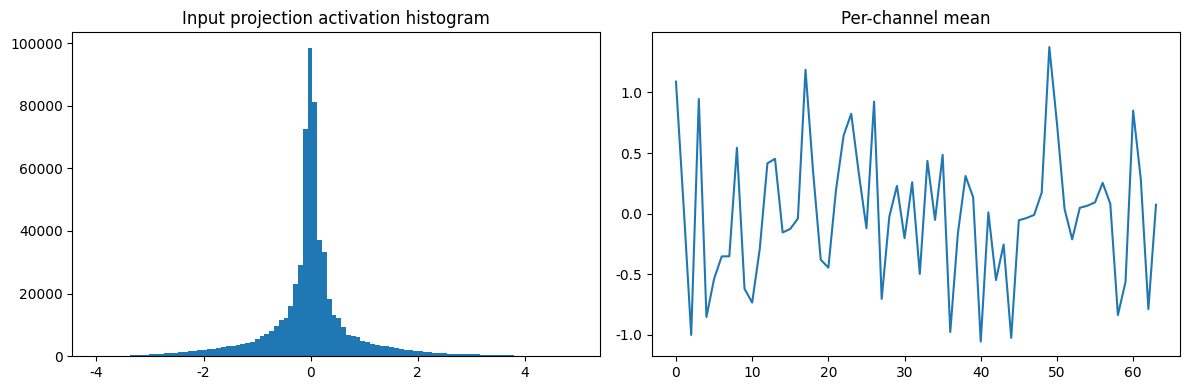

In [30]:
def inject_magnitude_ramp(x: torch.Tensor, mag_channel: int = 2, min_mag: float = 3.0, max_mag: float = 7.5):
    x_probe = x.clone()
    ramp = torch.linspace(min_mag, max_mag, steps=x_probe.size(1), device=x_probe.device)
    x_probe[:, :, mag_channel] = ramp.unsqueeze(0).expand(x_probe.size(0), -1)
    return x_probe


def capture_input_projection(model: torch.nn.Module, x: torch.Tensor) -> torch.Tensor:
    captured = []

    def _hook(_module, _inp, out):
        if isinstance(out, tuple):
            out = out[0]
        captured.append(out.detach().cpu())

    hook_handle = model.base_model.encoder.input_proj.register_forward_hook(_hook)
    try:
        with torch.no_grad():
            _ = model(x)
    finally:
        hook_handle.remove()

    if not captured:
        raise RuntimeError('No activations were captured from encoder.input_proj.')
    return captured[0]


def plot_activation_summary(h: torch.Tensor):
    print('mean:', float(h.mean()))
    print('std :', float(h.std()))
    print('min :', float(h.min()))
    print('max :', float(h.max()))

    channel_means = h.mean(dim=(0, 1)).numpy()
    h_flat = h.reshape(-1).numpy()

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.hist(h_flat, bins=100)
    plt.title('Input projection activation histogram')

    plt.subplot(1, 2, 2)
    plt.plot(channel_means)
    plt.title('Per-channel mean')
    plt.tight_layout()
    plt.show()


x_probe = inject_magnitude_ramp(x_eval, mag_channel=2, min_mag=3.0, max_mag=7.5)
h = capture_input_projection(model, x_probe)
plot_activation_summary(h)

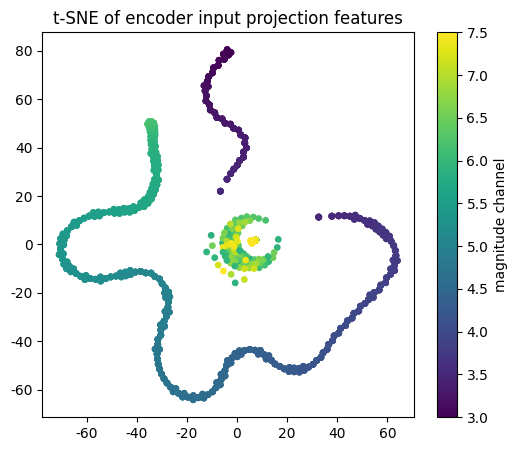

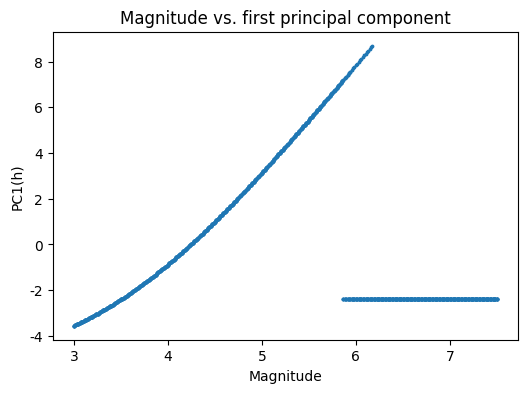

In [31]:
# Dimensional diagnostics: t-SNE and PCA
h_np = interp.to_numpy(h[:5]).reshape(-1, h.shape[-1])
labels = interp.to_numpy(x_probe[:5, :, 2]).reshape(-1)

X_emb = TSNE(n_components=2, random_state=42).fit_transform(h_np)
plt.figure(figsize=(6, 5))
sc = plt.scatter(X_emb[:, 0], X_emb[:, 1], c=labels, cmap='viridis', s=15)
plt.colorbar(sc, label='magnitude channel')
plt.title('t-SNE of encoder input projection features')
plt.show()

pc1 = PCA(n_components=1).fit_transform(h_np)[:, 0]
plt.figure(figsize=(6, 4))
plt.scatter(labels, pc1, s=3)
plt.xlabel('Magnitude')
plt.ylabel('PC1(h)')
plt.title('Magnitude vs. first principal component')
plt.show()

## 4) Regression Evaluation

Validation metrics:


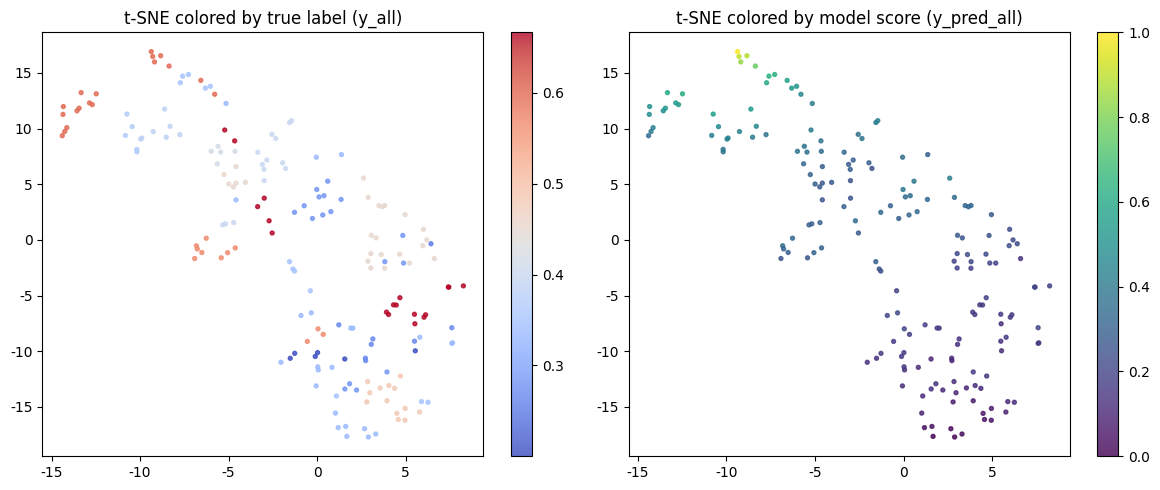

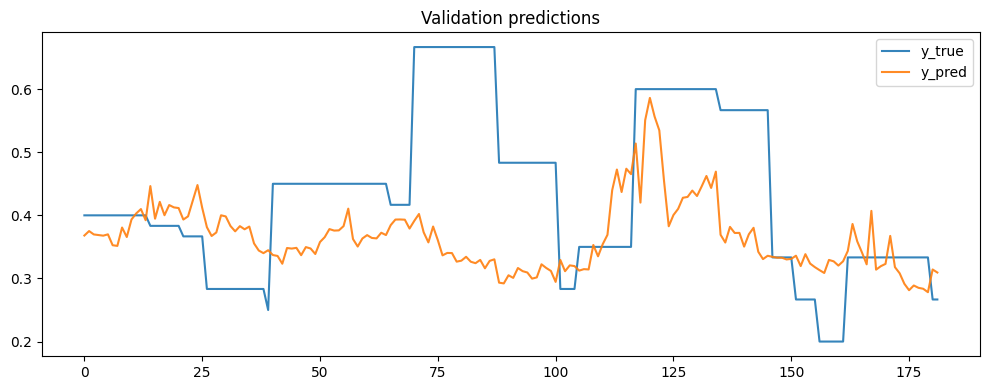

In [32]:
y_pred_val, y_val, X_val = analysis.predict_all(model, val_loader, DEVICE, return_X=True)

print('Validation metrics:')
regression_metrics(y_val, y_pred_val)

_X_scaled, _X_tsne, _y_score = analysis.tsne_scatter(X_val, y_val, y_pred_val)

plt.figure(figsize=(10, 4))
plt.plot(y_val, label='y_true', alpha=0.9)
plt.plot(y_pred_val, label='y_pred', alpha=0.9)
plt.title('Validation predictions')
plt.legend()
plt.tight_layout()
plt.show()

## 5) Interpretability

In [33]:
importlib.reload(interp)

IG_STEPS = 300
SAMPLE_IDX = 14

scores, labels = interp.compute_token_importance(
    model,
    x_eval,
    method='ig',
    n_steps=IG_STEPS,
    signed=True,
)

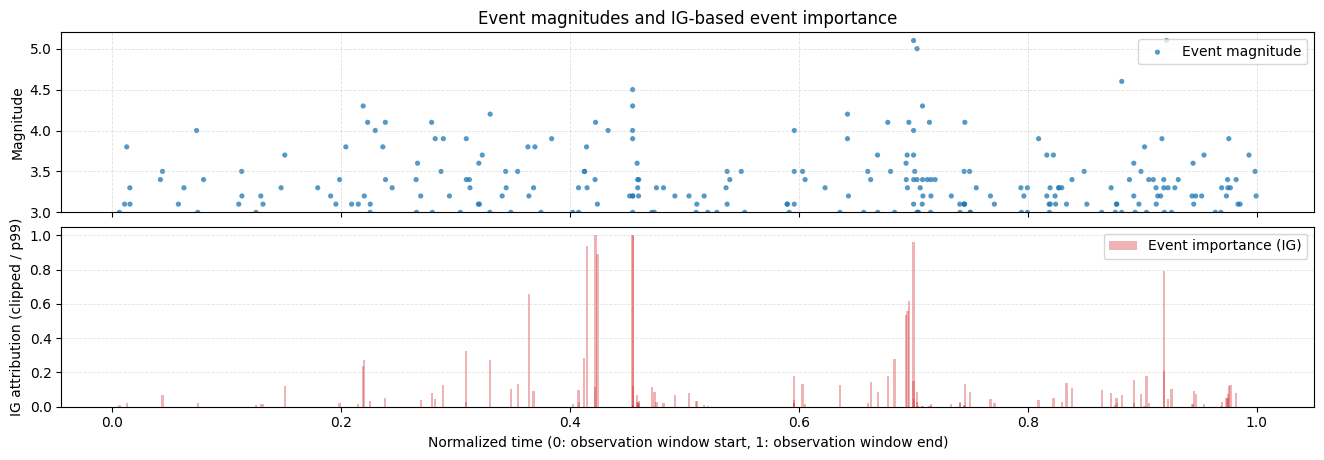

Top tokens by importance (index, score):
 1. idx=84  score=0.363396
 2. idx=77  score=0.103666
 3. idx=82  score=0.083222
 4. idx=137 score=0.077874
 5. idx=75  score=0.075831
 6. idx=78  score=0.072318
 7. idx=217 score=0.063985
 8. idx=64  score=0.052983
 9. idx=135 score=0.050091
10. idx=134 score=0.045382
11. idx=132 score=0.043159
12. idx=48  score=0.026237
13. idx=72  score=0.022782
14. idx=130 score=0.022501
15. idx=57  score=0.022284
16. idx=28  score=0.021933
17. idx=27  score=0.019297
18. idx=218 score=0.016825
19. idx=208 score=0.014539
20. idx=113 score=0.014463
Baseline prediction: 0.585867
Top-k deletion drops:
k= 1 drop=-0.020848
k= 2 drop=-0.015872
k= 5 drop=-0.019975
k=10 drop=0.234877
Least-k deletion drops (sanity):
k= 1 drop=0.000000
k= 2 drop=0.000000
k= 5 drop=0.000000
k=10 drop=0.000000


In [34]:
mask = get_non_pad_mask(x_eval[:, :, 0]).squeeze(-1).cpu().numpy().astype(bool)
fig = interp.plot_event_magnitude_and_importance_clean(
    x_eval,
    scores,
    batch_idx=SAMPLE_IDX,
    time_channel=1,
    mag_channel=2,
    importance_norm='p99',
    savepath=str(FIG_DIR / 'reg_interp.pdf'),
    mag_color='tab:blue',
    imp_color='tab:red',
    mask=mask,
    imp_ylim =None,
    height_ratios=(2, 2),
)

valid_mask = (x_eval[SAMPLE_IDX].abs().sum(dim=-1) > 0)
ranks = interp.rank_tokens_numeric(
    token_scores=scores,
    sample_idx=SAMPLE_IDX,
    valid_mask=valid_mask,
    topn=20,
)

print('Top tokens by importance (index, score):')
for i, (idx, score) in enumerate(ranks['top'], 1):
    print(f'{i:>2}. idx={idx:<3} score={score:.6f}')

validation = interp.deletion_validation_numeric(
    model=model,
    x=x_eval,
    token_scores=scores,
    sample_idx=SAMPLE_IDX,
    topk_list=(1, 2, 5, 10),
    deletion_mode='zero',
    baseline_strategy='zeros',
    valid_mask=valid_mask,
    return_details=True,
)

print(f"Baseline prediction: {validation['baseline']:.6f}")
print('Top-k deletion drops:')
for row in validation['results']['topk']:
    print(f"k={row['k']:>2} drop={row['drop']:.6f}")

print('Least-k deletion drops (sanity):')
for row in validation['results']['leastk']:
    print(f"k={row['k']:>2} drop={row['drop']:.6f}")

## 6) Batch Interpretability Export

observation window: 1972-12-23 00:17:35+00:00 to 1973-12-10 21:04:45+00:00 (duration: 352 days, 20:47:10)


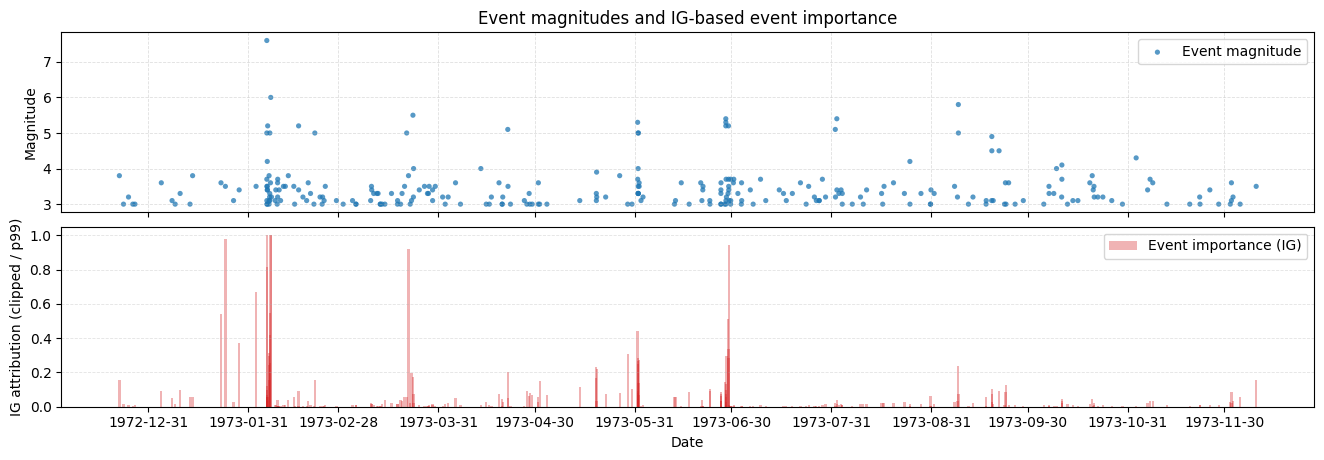

observation window: 1981-10-25 21:37:16+00:00 to 1982-10-18 17:41:43+00:00 (duration: 357 days, 20:04:27)


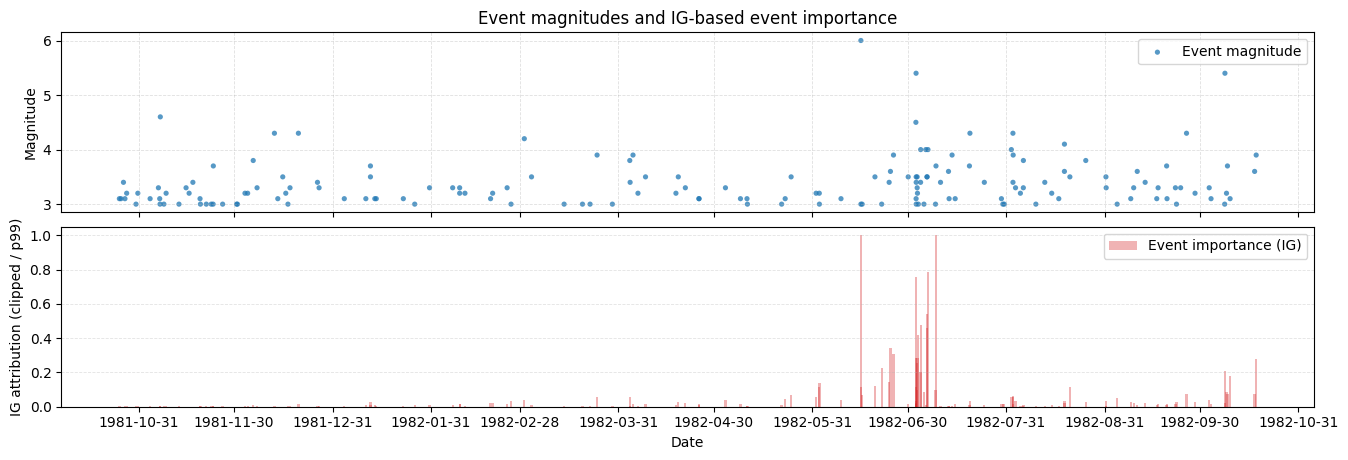

observation window: 1990-10-01 03:55:33+00:00 to 1991-09-20 02:25:33+00:00 (duration: 353 days, 22:30:00)


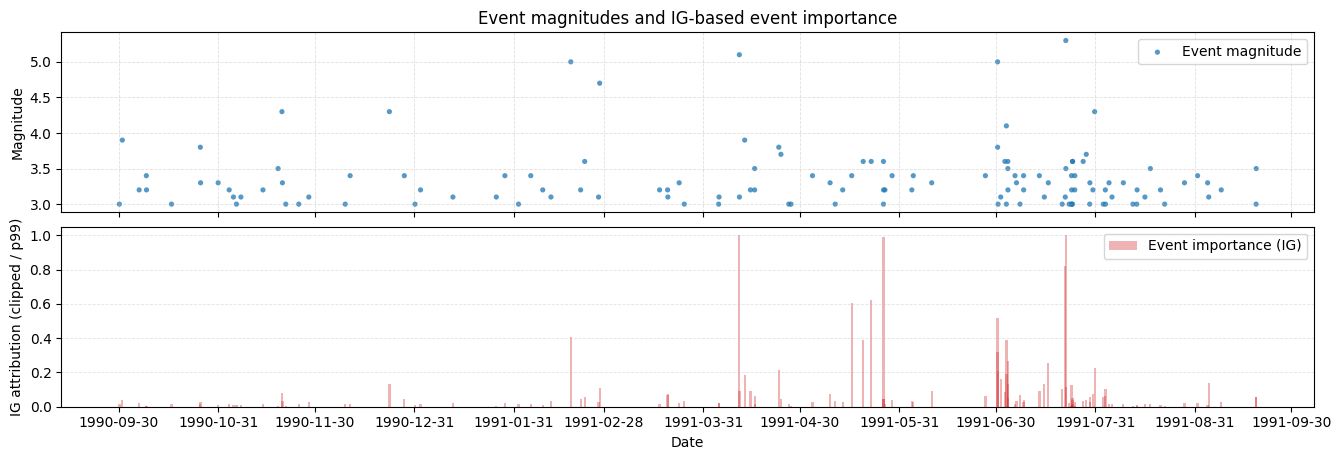

observation window: 1998-12-05 09:04:13+00:00 to 1999-11-28 18:52:02+00:00 (duration: 358 days, 9:47:49)


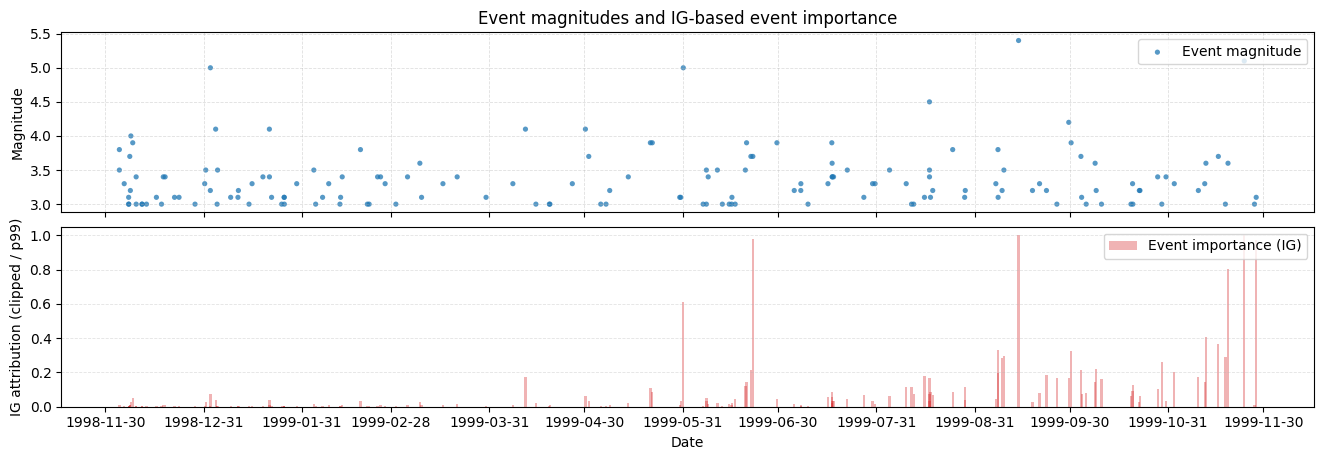

observation window: 2007-10-08 04:32:49+00:00 to 2008-10-01 21:02:49+00:00 (duration: 359 days, 16:30:00)


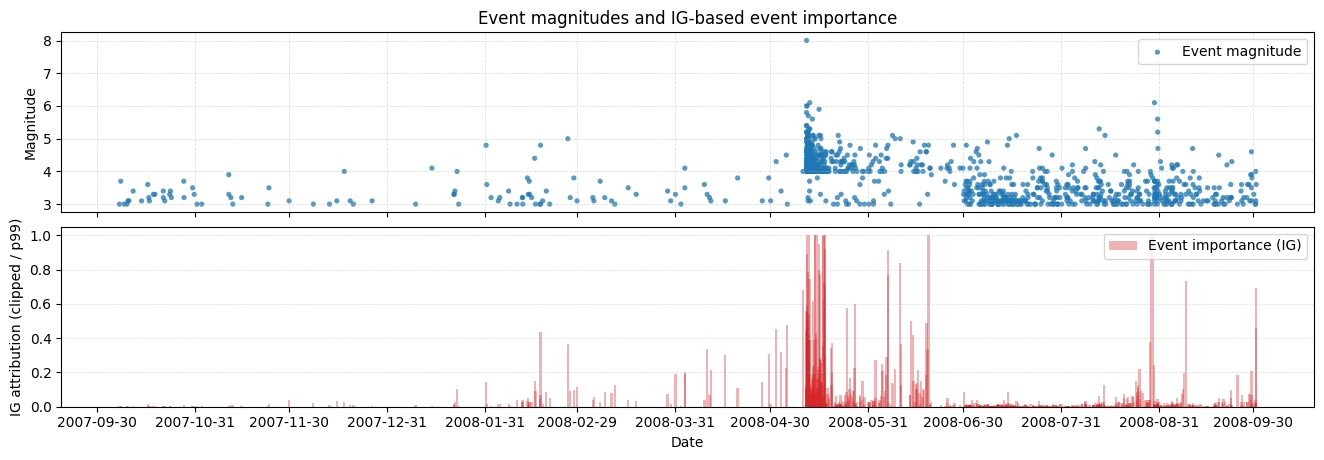

observation window: 2017-03-10 03:50:38+00:00 to 2018-03-02 01:18:45+00:00 (duration: 356 days, 21:28:07)


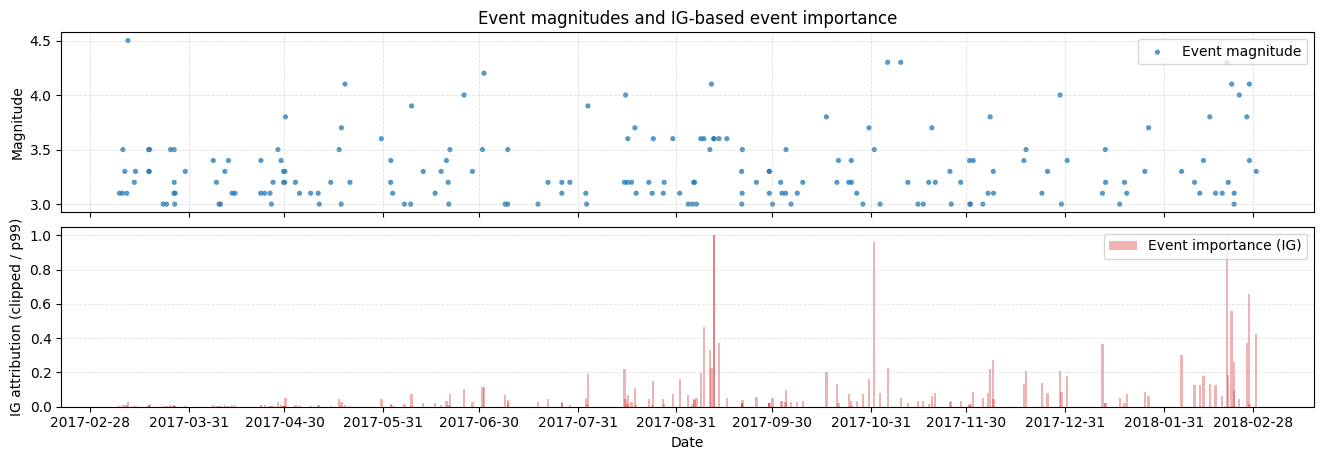

In [36]:
def batch_export_interpretability(
    model,
    data_loader,
    out_dir: Path,
    start_time,
    device: torch.device = DEVICE,
    every_n: int = 10,
    match_mod: int = 3,
    ig_steps: int = 200,
):
    out_dir.mkdir(parents=True, exist_ok=True)

    for batch_id, (x_batch, y_batch) in enumerate(data_loader):
        if batch_id % every_n != match_mod:
            continue

        x_batch = x_batch.to(device)
        sample_idx = np.random.randint(0, x_batch.shape[0])

        scores, _ = interp.compute_token_importance(
            model,
            x_batch,
            method='ig',
            n_steps=ig_steps,
            signed=False,
        )
        mask = get_non_pad_mask(x_batch[:, :, 0]).squeeze(-1).cpu().numpy().astype(bool)

        savepath = out_dir / f'reg_interp_{batch_id}_{sample_idx}.pdf'
        interp.plot_event_magnitude_and_importance_clean(
            x_batch,
            scores,
            batch_idx=sample_idx,
            time_channel=0,
            x_axis='time',
            start_time=start_time,
            time_scale=1.0,
            time_unit='D',
            mag_channel=2,
            importance_norm='p99',
            savepath=str(savepath),
            mag_color='tab:blue',
            imp_color='tab:red',
            mask=mask,
            height_ratios=(2, 2),
            xlabel='Date',
            clip_mag=None,
        )


set_seed(0)
batch_export_interpretability(
    model=model,
    data_loader=data_loader,
    out_dir=FIG_BATCH_DIR,
    start_time=t0_np,
    every_n=10,
    match_mod=3,
    ig_steps=200,
)